# 6.5 Regression Kriging with Graph Neural Networks



**Dataset:** Great Plains soil survey (`data/gp_data_5000.csv`, `data/gp_grid.csv`)  

**Target:** Soil Organic Carbon (SOC, %)  

**Covariates:** NDVI, MAP, MAT, elevation, slope, TPI, aspect, K-factor, silt+clay, **NLCD (categorical)**

**Library:** `pygstat` v0.1.0 — `GNNRegressionKriging`, `KCN`, `IGNNK`

***



## Table of Contents

1. [Overview](#1-overview)
2. [Mathematical Formulation](#2-mathematical-formulation)
3. [Python Setup](#3-python-setup)
4. [Load and Explore the Great Plains Data](#4-load-and-explore-the-great-plains-data)
5. [Prepare Features](#5-prepare-features)
6. [Stratified Train / Valid / Test Split](#6-stratified-train--valid--test-split)
7. [Exploratory Variogram of SOC](#7-exploratory-variogram-of-soc)
8. [Fit GNN Regression-Kriging Models](#8-fit-gnn-regression-kriging-models)
9. [Hold-Out Comparison on the Test Set](#9-hold-out-comparison-on-the-test-set)
10. [Feature Importance](#10-feature-importance)
11. [Predict SOC on Grid Locations](#11-predict-soc-on-grid-locations)
12. [Map Predictions](#12-map-predictions)
13. [CPU vs GPU RK Timing](#13-cpu-vs-gpu-rk-timing)
14. [Summary and Conclusions](#14-summary-and-conclusions)
15. [Resources](#15-resources)


***
## 1. Overview

**Regression Kriging (RK)** combines a **deterministic trend** with **ordinary kriging of the residuals**. At location $\mathbf{s}$,

$$
Z(\mathbf{s}) = \hat{m}(\mathbf{s}) + \hat{e}(\mathbf{s})
$$

where $\hat{m}(\mathbf{s})$ is the trend prediction and $\hat{e}(\mathbf{s})$ is the kriged residual. Tutorials 7.1–7.3 use scikit-learn ensembles, H2O, and a PyTorch MLP for $\hat{m}$. This notebook uses **graph neural networks** — models that treat sample locations as nodes in a spatial graph — via `pygstat.GNNRegressionKriging`, `pygstat.KCN`, and `pygstat.IGNNK`.

### 1.1 What a GNN is

A **Graph Neural Network** is a neural network that operates directly on graph-structured data: a set of **nodes** $V$ (each with a feature vector $x_v$), a set of **edges** $E$ (connections between nodes, optionally with edge features $e_{uv}$), and it learns a function of both the node features *and* the graph topology — instead of treating each sample as independent (like a standard MLP) or assuming a fixed grid/sequence (like a CNN/RNN).

The core mechanism is **message passing** (Gilmer et al., 2017): at each layer, every node aggregates information from its graph neighbors and updates its own representation.

$$
\mathbf{m}_v^{(k)} = \bigoplus_{u \in \mathcal{N}(v)} \text{MESSAGE}\big(\mathbf{h}_v^{(k-1)}, \mathbf{h}_u^{(k-1)}, e_{uv}\big), \qquad
\mathbf{h}_v^{(k)} = \text{UPDATE}\big(\mathbf{h}_v^{(k-1)}, \mathbf{m}_v^{(k)}\big)
$$

starting from $\mathbf{h}_v^{(0)} = x_v$, where $\mathcal{N}(v)$ is $v$'s neighbor set and $\bigoplus$ is a permutation-invariant aggregator (sum, mean, max, or an attention-weighted sum). After $K$ layers, each node's embedding $\mathbf{h}_v^{(K)}$ has absorbed information from its $K$-hop neighborhood, and a small head (e.g. an MLP) maps it to a prediction: $\hat{y}_v = \text{MLP}(\mathbf{h}_v^{(K)})$.

The classic **Graph Convolutional Network** (Kipf & Welling, 2017) is one concrete instance:

$$
H^{(k)} = \sigma\!\left(\tilde{D}^{-1/2}\tilde{A}\,\tilde{D}^{-1/2} H^{(k-1)} W^{(k)}\right), \qquad \tilde{A} = A + I,\ \tilde{D} = \text{diag}\Big(\sum_j \tilde{A}_{ij}\Big)
$$

— each layer is literally "average your neighbors' (and your own) features, then apply a learned linear transform and nonlinearity." Other well-known variants: **GraphSAGE** (Hamilton et al., 2017 — samples/aggregates neighbors, explicitly designed to generalize to nodes never seen during training) and **GAT** (Veličković et al., 2018 — learns *attention weights* per edge instead of fixed averaging).

### 1.2 Can GNNs be used for spatial mapping/interpolation?

**Yes**, and it's an active research area. The construction: treat each sample location as a node, connect nodes that are spatially near each other (k-nearest-neighbor graph, a distance-threshold graph, or a Delaunay triangulation), optionally weight edges by a distance kernel (e.g. $w_{uv} = \exp(-d_{uv}^2/2\ell^2)$ — deliberately covariance-shaped), attach any covariates as node features, and train the GNN to predict the target variable at each node. To predict at an unsampled location, you add it as a new node, connect it to its nearby existing neighbors, and run one forward pass.

That last step is the crux: a **transductive** GNN (plain GCN) is trained on one fixed graph and doesn't cleanly extend to brand-new nodes. For real spatial prediction you need an **inductive** architecture (GraphSAGE-style, or specifically designed for this), which is exactly what a couple of published methods do:

- **IGNNK** — *Inductive Graph Neural Networks for Spatiotemporal Kriging* (Wu, Cui, Nie, Wang, 2021) — trains a GNN by repeatedly masking random subsets of sensor nodes and having the network reconstruct them from their neighbors, then applies it to genuinely unmonitored locations. Explicitly framed as a Kriging replacement for sensor networks (traffic, air quality).
- **KCN** — *Kriging Convolutional Networks* (Appleby, Liu, Liu, 2020) — builds a GNN layer whose neighbor-aggregation is literally kriging-shaped (a learnable, distance-aware weighting), positioning itself as a direct hybrid.

So GNNs for mapping are real and used, particularly for **sensor networks and non-Euclidean domains** (river networks, road networks, irregular monitoring station layouts) where the graph structure carries real physical meaning beyond Euclidean distance.

### 1.3 How does this differ from kriging?

| | **Kriging** | **GNN** |
|---|---|---|
| **Foundation** | Explicit statistical model: a random function with a fitted covariance/variogram $C(h)$ | A flexible, nonlinear function approximator fit by gradient descent; no explicit spatial-process model |
| **Optimality** | Provably the **Best Linear Unbiased Estimator** given the covariance model | No such guarantee — whatever minimizes the training loss |
| **Uncertainty** | Exact, analytic kriging variance from the same covariance model | Not native — needs MC dropout / deep ensembles / quantile heads bolted on, generally less calibrated |
| **Exact interpolation** | Yes (with no nugget, reproduces data exactly at sample points) | Not inherently — has to be engineered in |
| **Data needed** | Works with tens–hundreds of points; no "training," just variogram fitting | Typically needs many nodes/graphs/timesteps to learn useful weights; small-$n$ tends to overfit |
| **Generalizing to new locations** | Trivial and automatic — any new point just gets its own covariance vector | Requires an *inductive* architecture (GraphSAGE/IGNNK-style); a plain GCN doesn't generalize to unseen nodes at all |
| **Covariates** | Regression/universal/co-kriging: linear trend + kriged residuals | Learns arbitrary nonlinear combinations of node features and graph structure jointly |
| **Nonstationarity, anisotropy** | Needs explicit extensions (universal kriging, factorial kriging, locally-varying variograms) | Can implicitly absorb nonstationary, nonlinear relationships from data, no explicit structural machinery required |
| **Interpretability** | Fully transparent — weights, variance, and drift terms are all derivable and inspectable | Largely a black box (attention weights offer partial insight) |
| **Cost profile** | Cheap to fit (variogram), $O(n^3)$-ish per local estimate (or reused factorization) | Expensive to train (GPU, many epochs), cheap per-node inference afterward |

**The short version:** kriging is a *statistically principled, small-data, exact-interpolation* method built on an explicit covariance model, with rigorous uncertainty quantification baked in. A GNN is a *flexible, large-data, nonlinear* learner that can absorb far richer covariate/topological structure (including non-Euclidean graphs like river or road networks) but gives up the statistical guarantees and needs deliberate engineering both to generalize to new nodes and to produce trustworthy uncertainty.

They're not mutually exclusive, either — note that a GCN layer with linear (no-nonlinearity) aggregation and edge weights set to normalized covariance values is *structurally* a locally-weighted average very much in the spirit of kriging, just without the unbiasedness Lagrange constraint that makes kriging BLUE. And the hybrid pattern used by KCN/IGNNK is exactly the **regression-kriging** idea already in this repo: use a learned model (there, a GNN; in [`regression_kriging.py`](../src/pygstat/regression_kriging.py)/[`regression_kriging_pytorch_gpu.py`](../src/pygstat/regression_kriging_pytorch_gpu.py), an ensemble or MLP) for the large-scale trend, then krige the leftover residuals for the fine-scale spatial correlation and its variance.


### GNN trend models in this notebook

`pygstat` wraps three inductive GNN trends. Each follows the same RK recipe: fit the GNN, krige its residuals with `OrdinaryKriging`, add the two back together. Graphs are $k$-nearest-neighbor graphs of the coordinates (`scipy.spatial.cKDTree`); aggregation is pure PyTorch (`index_add_`) — no `torch_geometric` dependency.

| Class | Architecture | What the node sees | How new locations are predicted |
|-------|--------------|--------------------|----------------------------------|
| `GNNRegressionKriging` | GraphSAGE-mean (`conv_type='mean'`) or GAT (`conv_type='gat'`) | Covariates only | Attach each query as a new node, connect it to its $k$ nearest **training** neighbors, one forward pass |
| `KCN` | Kriging Convolutional Network (Appleby et al., 2020) | Covariates **plus** neighbors' known target values, aggregated with a learnable-lengthscale Gaussian distance kernel. A node's **own** target is always hidden from itself | Same inductive attach; training nodes send known values as messages, query nodes do not |
| `IGNNK` | Inductive GNN for Kriging (Wu et al., 2021), adapted from spatiotemporal sensors to static RK | `[covariates, mask × value, mask]`. Training randomly masks a fraction of nodes each epoch and reconstructs them | Query nodes are attached with `mask=0` (unknown), training nodes remain known |

### This tutorial

We map **soil organic carbon** across the US Great Plains using **5,000** samples and a ~10 km prediction grid. **NLCD** land-cover class is **one-hot encoded** (a GNN sees a numeric matrix, same as tutorial 7.3). Samples are split **stratified by NLCD** into **train / valid / test**. All three GNN families (plus a GAT variant of the plain GNN) are fit on the training graph, scored on the **test set**, then used to **predict SOC at grid locations**. Section 13 times residual **ordinary kriging** on **CPU vs GPU** for prefixes of `data/gp_data_5000.csv`.


***
## 2. Mathematical Formulation

The target $Z(\mathbf{s})$ at location $\mathbf{s}$ is

$$
Z(\mathbf{s}) = \mu(\mathbf{s}) + \varepsilon(\mathbf{s})
$$

where $\mu(\mathbf{s})$ is a **deterministic trend** explained by covariates (and, for KCN/IGNNK, by neighboring observed values) and $\varepsilon(\mathbf{s})$ is a **zero-mean, spatially autocorrelated residual**.

### Spatial graph

Given training coordinates $\{\mathbf{s}_i\}_{i=1}^{n}$, build a directed $k$-nearest-neighbor graph. For each node $v$, the $k$ nearest *other* training locations are sources; self-loops are excluded.

$$
\mathcal{N}(v) = \operatorname{kNN}(\mathbf{s}_v;\, k),\qquad
E = \bigl\{(u \to v): u \in \mathcal{N}(v)\bigr\}
$$

To predict at new locations $\{\mathbf{s}_0\}$, attach each query as a destination whose sources are its $k$ nearest **training** nodes. Query-to-query and query-to-train reverse edges are never added — this is what makes the models **inductive**.

### Plain GNN trend (`GNNRegressionKriging`)

Covariates $\mathbf{x}(\mathbf{s})$ are standardized. Each GraphSAGE-mean layer is

$$
\mathbf{h}_v^{(k)} = W_{\mathrm{self}}^{(k)}\mathbf{h}_v^{(k-1)} + W_{\mathrm{neigh}}^{(k)}\!\left(\frac{1}{|\mathcal{N}(v)|}\sum_{u \in \mathcal{N}(v)}\mathbf{h}_u^{(k-1)}\right)
$$

followed by ReLU and dropout. GAT replaces the uniform mean with learned attention weights $\alpha_{uv}$. A linear head maps the final embedding to $\hat{\mu}(\mathbf{s})$. New nodes receive messages from training neighbors only; they never send messages back.

### KCN trend

Node features are $[\mathbf{x},\; \text{mask}\cdot y,\; \text{mask}]$. The first layer is a **Kriging Convolution**: neighbors are weighted by a Gaussian kernel of spatial distance with a learnable lengthscale $\ell$,

$$
w_{uv} = \exp\!\left(-\frac{d(\mathbf{s}_u,\mathbf{s}_v)^2}{2\ell^2}\right),\qquad
\mathbf{h}_v = \sigma\!\left(W_{\mathrm{self}}\,\mathbf{x}_v^{\mathrm{self}} + W_{\mathrm{neigh}}\sum_{u \in \mathcal{N}(v)} \tilde{w}_{uv}\,\mathbf{x}_u^{\mathrm{msg}}\right)
$$

where $\mathbf{x}_v^{\mathrm{self}}$ **always zeroes** the node's own target and mask flag (leave-self-out — otherwise the network would copy $y_v$), while $\mathbf{x}_u^{\mathrm{msg}}$ reveals $y_u$ wherever it is actually known. Further layers are ordinary mean aggregations on the resulting hidden states.

### IGNNK trend

Every node carries $[\mathbf{x},\; m\cdot y,\; m]$. Each training epoch draws a random mask over a fraction `mask_ratio` of the non-validation nodes and trains the GNN to reconstruct those hidden values from the (partially also-masked) graph. At prediction time query nodes have $m=0$. Residuals on the training set are computed by **$k$-fold masked reconstruction** so a node is never scored on a pass where its own $y$ was visible.

### Residuals and variogram

$$
e_i = z_i - \hat{\mu}(\mathbf{s}_i), \quad i = 1, \ldots, n_{\mathrm{train}}
$$

$$
\hat{\gamma}(h) = \frac{1}{2|N(h)|} \sum_{(i,j) \in N(h)} (e_i - e_j)^2
$$

Spherical model:

$$
\gamma(h) =
\begin{cases}
c_0 + c \left(1.5 \frac{h}{a} - 0.5 \left(\frac{h}{a}\right)^3 \right), & h < a \\
c_0 + c, & h \geq a
\end{cases}
$$

### Ordinary kriging of residuals

$$
\hat{\varepsilon}(\mathbf{s}_0) = \sum_{i=1}^{n} \lambda_i e_i
$$

with the usual unbiasedness constraint $\sum_i \lambda_i = 1$. Final prediction:

$$
\hat{Z}(\mathbf{s}_0) = \hat{\mu}(\mathbf{s}_0) + \hat{\varepsilon}(\mathbf{s}_0)
$$

Kriging variance $\sigma_K^2(\mathbf{s}_0)$ is reported as a standard error when `return_std=True`. This is the GNN analogue of the MLP workflow in tutorial 7.3: the network captures a **nonlinear, neighborhood-aware trend**; kriging adds **local spatial structure** and a calibrated residual variance.

### Why a GNN for the trend?

| Method | Pros | Cons |
|--------|------|------|
| sklearn ensembles (tutorial 7.1) | Simple Python API, native importances | Independent samples; no explicit neighborhood |
| H2O GLM / DRF / GBM / AutoML (tutorial 7.2) | Native categoricals, grid search | Requires Java / H2O cluster |
| PyTorch MLP (tutorial 7.3) | Nonlinear capacity, GPU, Optuna | Treats locations as i.i.d. given covariates |
| Spatial GNN (this notebook) | Uses topology; KCN/IGNNK propagate observed values; inductive to new sites | Needs enough nodes; less interpretable; extra graph hyperparameters ($k$, mask ratio) |

### Real-world example: soil organic carbon

- **Covariates:** NDVI, MAP, MAT, elevation, slope, TPI, aspect, K-factor, silt+clay, NLCD class
- **Graph:** $k$-nearest neighbors in Albers metres — nearby soil profiles share climate and land-cover context
- **Trend:** the GNN can mix a location's own covariates with those of its neighbors (and, for KCN/IGNNK, their measured SOC)
- **Residuals:** unmeasured soil type, management, and local climate still left for kriging


***
## 3. Python Setup

### 3.1 CPU and GPU

`GNNRegressionKriging`, `KCN`, and `IGNNK` each have two independent backends:

| Argument | What it controls |
|----------|------------------|
| `device` | PyTorch GNN training / inference (`'cpu'` or `'cuda'`). |
| `use_gpu` | Residual **ordinary kriging** covariance + solve (NumPy or CuPy). |

`use_gpu` is:

| Value | Behaviour |
|-------|-----------|
| `'auto'` (default) | GPU when CuPy can run a kernel on this card. Falls back to CPU otherwise. |
| `True` | Force GPU. Warns and falls back to CPU if CuPy is missing or cannot run a kernel. |
| `False` | Always CPU (NumPy/SciPy). |

This notebook probes the GPU once with `cupy_gpu_usable()` (a real op, not just `import cupy`) and stores the result in `USE_GPU`. Every GNN regression-kriging constructor below passes `use_gpu=USE_GPU`. The GNN still uses `device=DEVICE` (PyTorch CUDA, which can be unavailable even when CuPy works).

Install CuPy with `pip install pygstat[gpu]` (CUDA 11) or `pip install cupy-cuda12x` for CUDA 12.

Section 13 times residual OK (the kriging step inside the GNN RK classes) on both backends using prefixes of `data/gp_data_5000.csv`.


In [1]:
%matplotlib inline

import os
import sys
import warnings
from collections import Counter
from pathlib import Path

# pygstat optionally imports TensorFlow for DeepRegressionKrigingTF.
# Loading that stack in the same process as PyTorch can crash; keep TF out.
sys.modules.setdefault("tensorflow", None)

sys.path.insert(0, os.path.abspath("../src"))

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder

from IPython.display import display
import pygstat
from pygstat import GNNRegressionKriging, IGNNK, KCN, Variogram
from pygstat.utils.backend import CUPY_AVAILABLE, cupy_gpu_usable

warnings.filterwarnings("ignore", category=UserWarning)
pd.set_option("display.float_format", lambda v: f"{v:0.3f}")

print("torch version :", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
DEVICE = "cpu"
if torch.cuda.is_available():
    major, minor = torch.cuda.get_device_capability(0)
    print("GPU           :", torch.cuda.get_device_name(0), f"(sm_{major}{minor})")
    # This wheel ships kernels for sm_75+; older cards fall back to CPU.
    if (major, minor) >= (7, 5):
        DEVICE = "cuda"
    else:
        print("GPU compute capability is below sm_75; using CPU")
print("Using device :", DEVICE)

# ── Residual OK: CPU / GPU dispatch (CuPy; independent of PyTorch DEVICE) ─────
# cupy_gpu_usable() runs a real kernel (not just `import cupy`). Older cards can
# import CuPy and still fail at compile time; those stay on CPU.
print(f"pygstat version : {pygstat.__version__}")
USE_GPU = cupy_gpu_usable()
if USE_GPU:
    import cupy as cp
    print(f"CuPy            : {cp.__version__}")
    try:
        name = cp.cuda.runtime.getDeviceProperties(0)["name"]
        if isinstance(name, bytes):
            name = name.decode()
        print(f"GPU (CuPy)      : {name}")
    except Exception:
        print("GPU (CuPy)      : available")
    print("Backend         : GPU (CuPy) — residual OK covariance + solve on GPU")
else:
    if CUPY_AVAILABLE:
        import cupy as cp
        print(f"CuPy            : {cp.__version__} (installed, but cannot run a kernel on this GPU/CUDA setup)")
    else:
        print("CuPy            : not installed  (pip install pygstat[gpu]  or  cupy-cuda12x)")
    print("Backend         : CPU (NumPy)")
print(f"use_gpu         : {USE_GPU}")


torch version : 2.13.0+cu132
CUDA available: False
Using device : cpu
pygstat version : 0.1.0
CuPy            : 14.2.0
GPU (CuPy)      : NVIDIA GeForce RTX 2080 Ti
Backend         : GPU (CuPy) — residual OK covariance + solve on GPU
use_gpu         : True


***
## 4. Load and Explore the Great Plains Data

Point samples live in `data/gp_data_5000.csv` (SOC plus covariates at 5,000 locations). The prediction grid is `data/gp_grid.csv` (covariates only). Coordinates are US Albers Equal Area (EPSG:5070), in metres.

The CSV header repeats `NLCD`; pandas renames the second copy to `NLCD.1`. That extra column is dropped. The first `NLCD` column matches the grid (classes 3–7).


In [2]:
DATA_DIR = Path("..") / "data"
df = pd.read_csv(DATA_DIR / "gp_data_5000.csv")
grid_df = pd.read_csv(DATA_DIR / "gp_grid.csv")
df = df.drop(columns=["NLCD.1"], errors="ignore")

print(f"Samples: {len(df):,}  |  Grid nodes: {len(grid_df):,}")
print("Sample columns:", list(df.columns))
print("Grid columns  :", list(grid_df.columns))
df.head()


Samples: 5,000  |  Grid nodes: 10,674
Sample columns: ['x', 'y', 'Aspect', 'ELEV', 'FRG', 'K_Factor', 'MAP', 'MAT', 'NDVI', 'NLCD', 'Silt_Clay', 'Slope', 'TPI', 'SOC']
Grid columns  : ['x', 'y', 'Aspect', 'ELEV', 'FRG', 'K_Factor', 'MAP', 'MAT', 'NDVI', 'NLCD', 'Silt_Clay', 'Slope', 'TPI']


,x,y,Aspect,ELEV,FRG,K_Factor,MAP,MAT,NDVI,NLCD,Silt_Clay,Slope,TPI,SOC
0,-955285,1723795,190.940,3253.481,3,0.215,509.138,1.762,0.556,4,43.669,16.048,-10.496,7.543
1,-735285,1973795,151.478,1464.636,2,0.213,346.082,9.494,0.598,7,48.345,1.105,-0.606,6.102
2,-975285,1103795,129.981,1441.645,133,0.113,372.746,15.772,0.240,5,38.460,12.090,2.134,3.612
3,-395285,1883795,143.176,841.139,2,0.320,548.891,10.720,0.483,6,87.090,2.587,-0.656,7.510
4,-925285,1173795,224.582,1490.576,3,0.284,357.764,14.428,0.216,5,53.868,6.122,0.595,2.378


In [3]:
print(df[["SOC", "NDVI", "MAP", "MAT", "ELEV", "Silt_Clay"]].describe().round(2))

NLCD_DES = {
    3: "Barren / other",
    4: "Forest",
    5: "Shrubland",
    6: "Herbaceous",
    7: "Planted/Cultivated",
}
print("\nNLCD classes (samples):")
print(
    df.groupby("NLCD").size().rename("n").to_frame()
    .assign(description=lambda s: s.index.map(NLCD_DES))
)


           SOC     NDVI      MAP      MAT     ELEV  Silt_Clay
count 5000.000 5000.000 5000.000 5000.000 5000.000   5000.000
mean     6.030    0.410  488.670    9.100 1657.040     53.890
std      3.700    0.160  213.480    4.180  743.290     16.410
min      0.030    0.050  153.580   -2.520  234.550      1.750
25%      3.240    0.270  345.480    6.290 1207.240     42.360
50%      5.120    0.380  424.780    9.570 1656.710     52.610
75%      8.030    0.530  585.630   12.420 2175.490     62.700
max     23.750    0.820 1749.110   17.880 3688.660     90.740

NLCD classes (samples):
         n         description
NLCD                          
3       19      Barren / other
4      956              Forest
5     1657           Shrubland
6     1519          Herbaceous
7      849  Planted/Cultivated


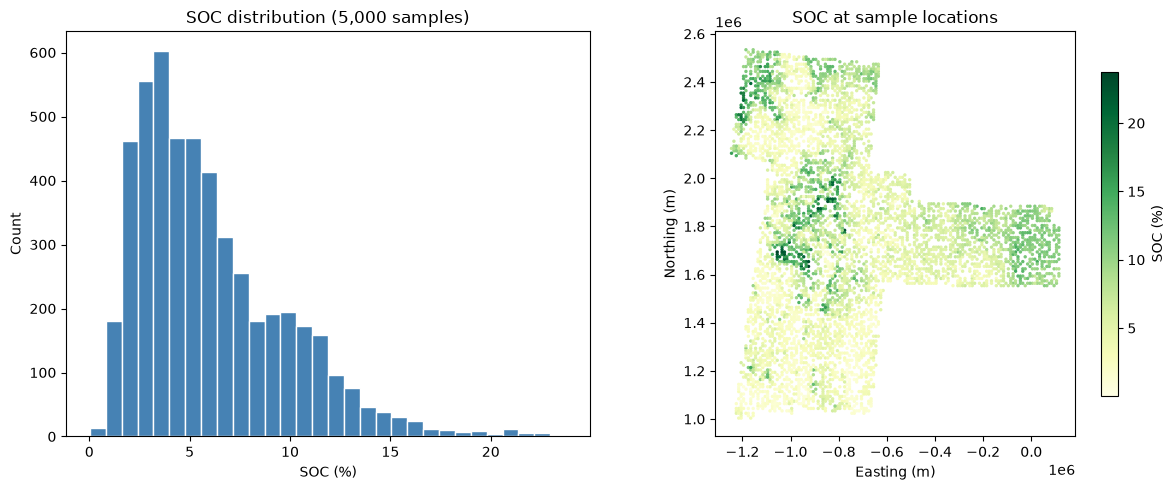

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].hist(df["SOC"], bins=30, color="steelblue", edgecolor="white")
axes[0].set_xlabel("SOC (%)")
axes[0].set_ylabel("Count")
axes[0].set_title("SOC distribution (5,000 samples)")

sc = axes[1].scatter(df["x"], df["y"], c=df["SOC"], s=6, cmap="YlGn", edgecolors="none")
axes[1].set_xlabel("Easting (m)")
axes[1].set_ylabel("Northing (m)")
axes[1].set_title("SOC at sample locations")
axes[1].set_aspect("equal", adjustable="box")
fig.colorbar(sc, ax=axes[1], label="SOC (%)", shrink=0.8)
plt.tight_layout()
plt.show()


***
## 5. Prepare Features

Unlike tutorial 7.2, **NLCD is not a native H2O factor**. A GNN (like the PyTorch MLP in tutorial 7.3) sees a numeric matrix, so land cover is **one-hot encoded**:

- `OneHotEncoder(drop="first")` creates dummy columns and drops the first class as the baseline.
- The encoder is fit on the sample table and applied to the prediction grid (`handle_unknown="ignore"`).


In [5]:
required_cols = [
    "x", "y", "NDVI", "MAP", "MAT", "ELEV", "Slope", "TPI",
    "Aspect", "K_Factor", "Silt_Clay", "NLCD",
]
for col in required_cols:
    if col not in df.columns or col not in grid_df.columns:
        raise ValueError(f"Missing column: {col}")

numeric_cols = [
    "NDVI", "MAP", "MAT", "ELEV", "Slope", "TPI",
    "Aspect", "K_Factor", "Silt_Clay",
]
cat_cols = ["NLCD"]

encoder = OneHotEncoder(
    drop="first",
    handle_unknown="ignore",
    sparse_output=False,
    dtype=float,
)
encoder.fit(df[cat_cols])
nlcd_dummy_names = encoder.get_feature_names_out(cat_cols).tolist()
encoded_feature_names = numeric_cols + nlcd_dummy_names
baseline = encoder.categories_[0][0]


def encode_X(frame):
    num = frame[numeric_cols].to_numpy(dtype=float)
    cat = encoder.transform(frame[cat_cols])
    return np.hstack([num, cat])


X = encode_X(df)
y = df["SOC"].to_numpy(dtype=float)
coords = df[["x", "y"]].to_numpy(dtype=float)
X_grid = encode_X(grid_df)
coords_grid = grid_df[["x", "y"]].to_numpy(dtype=float)
nlcd_labels = df["NLCD"].to_numpy()

print("Numeric features:", numeric_cols)
print("NLCD categories :", list(encoder.categories_[0]))
print(f"Dropped baseline: {int(baseline)} ({NLCD_DES.get(int(baseline), '?')})")
print("Dummy columns   :", nlcd_dummy_names)
print("Encoded features:", encoded_feature_names)
print("X:", X.shape, "  y:", y.shape, "  coords:", coords.shape)
print("Grid X:", X_grid.shape)


Numeric features: ['NDVI', 'MAP', 'MAT', 'ELEV', 'Slope', 'TPI', 'Aspect', 'K_Factor', 'Silt_Clay']
NLCD categories : [np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7)]
Dropped baseline: 3 (Barren / other)
Dummy columns   : ['NLCD_4', 'NLCD_5', 'NLCD_6', 'NLCD_7']
Encoded features: ['NDVI', 'MAP', 'MAT', 'ELEV', 'Slope', 'TPI', 'Aspect', 'K_Factor', 'Silt_Clay', 'NLCD_4', 'NLCD_5', 'NLCD_6', 'NLCD_7']
X: (5000, 13)   y: (5000,)   coords: (5000, 2)
Grid X: (10674, 13)


***
## 6. Stratified Train / Valid / Test Split

A **60% / 20% / 20%** split, stratified by NLCD so each land-cover class appears in train, valid, and test (`random_state=42`).

- **Train + valid** — passed to `fit()`. Each GNN builds its $k$-NN graph on these coordinates and carves an internal validation subset (`val_fraction`) for early stopping. Residual kriging is fit on the same coordinates.
- **Test** — untouched hold-out used only after the four GNN families are compared

The GNN `fit()` API does not take a separate `X_val` tensor (unlike `DeepRegressionKriging` in tutorial 7.3): validation nodes stay **in the graph** so they can send messages, but they are excluded from the training loss.


In [6]:
counts = Counter(nlcd_labels)
stratify_arg = nlcd_labels if min(counts.values()) >= 3 else None

(
    X_temp, X_test,
    y_temp, y_test,
    coords_temp, coords_test,
    nlcd_temp, nlcd_test,
) = train_test_split(
    X, y, coords, nlcd_labels,
    test_size=0.20,
    random_state=42,
    shuffle=True,
    stratify=stratify_arg,
)

(
    X_train, X_valid,
    y_train, y_valid,
    coords_train, coords_valid,
    nlcd_train, nlcd_valid,
) = train_test_split(
    X_temp, y_temp, coords_temp, nlcd_temp,
    test_size=0.25,  # 0.25 * 0.80 = 0.20 overall
    random_state=42,
    shuffle=True,
    stratify=nlcd_temp if stratify_arg is not None else None,
)

X_fit = np.vstack([X_train, X_valid])
y_fit = np.concatenate([y_train, y_valid])
coords_fit = np.vstack([coords_train, coords_valid])


def _nlcd_counts(arr):
    return sorted(Counter(arr).items())


print(f"Train: {len(X_train):,}  |  Valid: {len(X_valid):,}  |  Test: {len(X_test):,}")
print(f"Fit graph (train+valid): {len(X_fit):,}")
print("NLCD train:", _nlcd_counts(nlcd_train))
print("NLCD valid:", _nlcd_counts(nlcd_valid))
print("NLCD test :", _nlcd_counts(nlcd_test))


Train: 3,000  |  Valid: 1,000  |  Test: 1,000
Fit graph (train+valid): 4,000
NLCD train: [(np.int64(3), 11), (np.int64(4), 574), (np.int64(5), 995), (np.int64(6), 911), (np.int64(7), 509)]
NLCD valid: [(np.int64(3), 4), (np.int64(4), 191), (np.int64(5), 331), (np.int64(6), 304), (np.int64(7), 170)]
NLCD test : [(np.int64(3), 4), (np.int64(4), 191), (np.int64(5), 331), (np.int64(6), 304), (np.int64(7), 170)]


***
## 7. Exploratory Variogram of SOC

Before residual kriging, look at the **raw SOC** variogram on the training coordinates. Lag count uses Scott's rule on pairwise distances, capped at 30 lags: bin width $h = 3.5 \, \mathrm{std}\,/\, n^{1/3}$.


In [7]:
# Scott's rule on a random subset keeps the n=3,000 distance matrix light
rng = np.random.default_rng(42)
idx = rng.choice(len(coords_train), size=min(1200, len(coords_train)), replace=False)
sample_xy = coords_train[idx]
distances = np.sqrt(((sample_xy[:, None, :] - sample_xy[None, :, :]) ** 2).sum(axis=2))
upper_triangle = distances[np.triu_indices_from(distances, k=1)]
std_dist = np.nanstd(upper_triangle)
n_pairs = len(upper_triangle)
scott_bin_width = 3.5 * std_dist / (n_pairs ** (1 / 3))
maxlag_soc = float(np.nanpercentile(upper_triangle, 50))
n_lags_soc = max(5, min(30, int(maxlag_soc / scott_bin_width)))
print(f"Using Scott rule → n_lags: {n_lags_soc}, maxlag: {maxlag_soc:.1f} m")


Using Scott rule → n_lags: 30, maxlag: 601664.4 m


In [8]:
vg = Variogram(
    coords_train, y_train,
    model="spherical",
    estimator="matheron",
    maxlag=maxlag_soc,
    n_lags=n_lags_soc,
    use_gpu="auto",
)
vg.fit()
mask = ~np.isnan(vg.experimental)
rmse_vg = np.sqrt(np.mean((vg.experimental[mask] - vg(vg.lags)[mask]) ** 2))
nugget, psill, rng_m = vg.fitted_params
print(f"Spherical model RMSE: {rmse_vg:.2f}")
print(f"nugget={nugget:.3f}, partial sill={psill:.3f}, range={rng_m:.1f} m")


Spherical model RMSE: 0.51
nugget=3.209, partial sill=10.594, range=300832.2 m


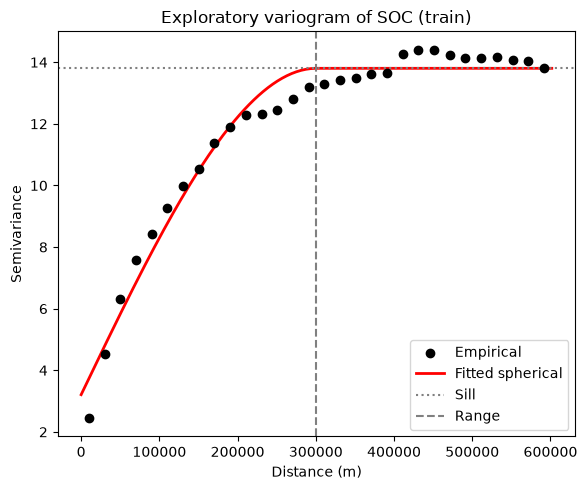

In [9]:
plt.figure(figsize=(6, 5))
plt.scatter(vg.lags, vg.experimental, color="black", label="Empirical", zorder=3)
h_fine = np.linspace(0, vg.maxlag, 200)
plt.plot(h_fine, vg(h_fine), color="red", linewidth=2, label="Fitted spherical")
plt.axhline(nugget + psill, color="gray", linestyle=":", label="Sill")
plt.axvline(rng_m, color="gray", linestyle="--", label="Range")
plt.xlabel("Distance (m)")
plt.ylabel("Semivariance")
plt.title("Exploratory variogram of SOC (train)")
plt.legend()
plt.tight_layout()
plt.show()


Residual variograms (next section) typically have a **shorter range** than the raw SOC variogram, because the regression has already absorbed the large-scale trend. Residual models use `maxlag=50` km and 15 lags — the same setting as tutorials 7.1–7.3.


***
## 8. Fit GNN Regression-Kriging Models

Four trend families are fit on the same train+valid graph (`coords_fit`):

1. **`sage`** — `GNNRegressionKriging(conv_type='mean')`, GraphSAGE-style mean aggregation of covariates.
2. **`gat`** — same class with `conv_type='gat'`: learned attention weights per edge (Veličković et al., 2018).
3. **`kcn`** — `KCN`: leave-self-out Gaussian-kernel convolution of neighbors' known SOC (Appleby et al., 2020).
4. **`ignnk`** — `IGNNK`: random-mask reconstruction so the trend generalizes to never-seen nodes (Wu et al., 2021).

Hyperparameters follow `tests/test_regression_kriging_gnn.py` (full-dataset settings), with a slightly larger epoch budget for the tutorial. Residual variograms use a spherical model, `maxlag=50` km, 15 lags.


In [10]:
VARIOGRAM_KWARGS = {"maxlag": 50_000, "n_lags": 15}

COMMON = dict(
    device=DEVICE,
    use_gpu=USE_GPU,
    seed=1,
    variogram_model="spherical",
    variogram_kwargs=VARIOGRAM_KWARGS,
)

specs = {
    "sage": (
        GNNRegressionKriging,
        dict(k_neighbors=12, hidden_dim=64, n_layers=2, conv_type="mean",
             max_epochs=80, patience=15),
    ),
    "gat": (
        GNNRegressionKriging,
        dict(k_neighbors=12, hidden_dim=64, n_layers=2, conv_type="gat",
             max_epochs=80, patience=15),
    ),
    "kcn": (
        KCN,
        dict(k_neighbors=12, hidden_dim=64, n_layers=2,
             max_epochs=80, patience=15),
    ),
    "ignnk": (
        IGNNK,
        dict(k_neighbors=12, hidden_dim=64, n_layers=3, mask_ratio=0.3,
             max_epochs=100, patience=20),
    ),
}

fitted = {}
for name, (cls, kwargs) in specs.items():
    print(f"\n=== Fitting {name} ({cls.__name__}) ===")
    rk = cls(**COMMON, **kwargs)
    rk.fit(X_fit, y_fit, coords_fit, verbose=False)
    n_ep = len(rk.train_losses_)
    print(f"{rk}")
    print(f"stopped at epoch {n_ep}: "
          f"train={rk.train_losses_[-1]:.4f}, val={rk.val_losses_[-1]:.4f}")
    fitted[name] = rk



=== Fitting sage (GNNRegressionKriging) ===


GNNRegressionKriging(conv_type='mean', k_neighbors=12, variogram_model='spherical')
stopped at epoch 80: train=0.1723, val=0.1844

=== Fitting gat (GNNRegressionKriging) ===


GNNRegressionKriging(conv_type='gat', k_neighbors=12, variogram_model='spherical')
stopped at epoch 80: train=0.2893, val=0.3122

=== Fitting kcn (KCN) ===


KCN(k_neighbors=12, lengthscale~2.24e+04, variogram_model='spherical')
stopped at epoch 80: train=0.1471, val=0.1369

=== Fitting ignnk (IGNNK) ===


IGNNK(k_neighbors=12, mask_ratio=0.3, variogram_model='spherical')
stopped at epoch 100: train=0.1443, val=0.1395


Training curves for each fitted GNN. Validation loss is the early-stopping signal (`val_fraction=0.15` of the fit-graph nodes, held out of the training loss but still present in the graph).


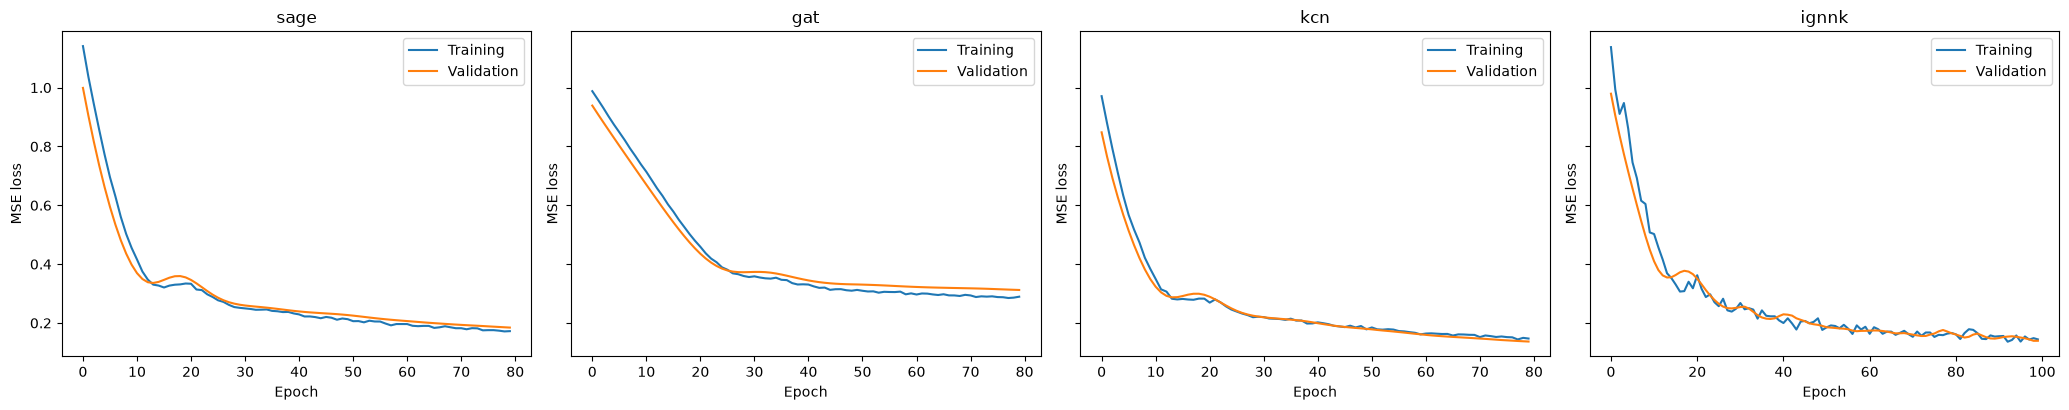

In [11]:
n = len(fitted)
fig, axes = plt.subplots(1, n, figsize=(5.2 * n, 4.2), sharey=True)
if n <= 1:
    axes = [axes]
for ax, (name, rk) in zip(np.atleast_1d(axes).ravel(), fitted.items()):
    ax.plot(rk.train_losses_, label="Training")
    if rk.val_losses_ is not None:
        ax.plot(rk.val_losses_, label="Validation")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("MSE loss")
    ax.set_title(name)
    ax.legend()
plt.tight_layout()
plt.show()


A subsample of the $k$-NN training graph (GraphSAGE / KCN / IGNNK share the same construction). Edges point from each node's $k$ nearest neighbors; the map uses the `sage` model's stored `edge_index_`.


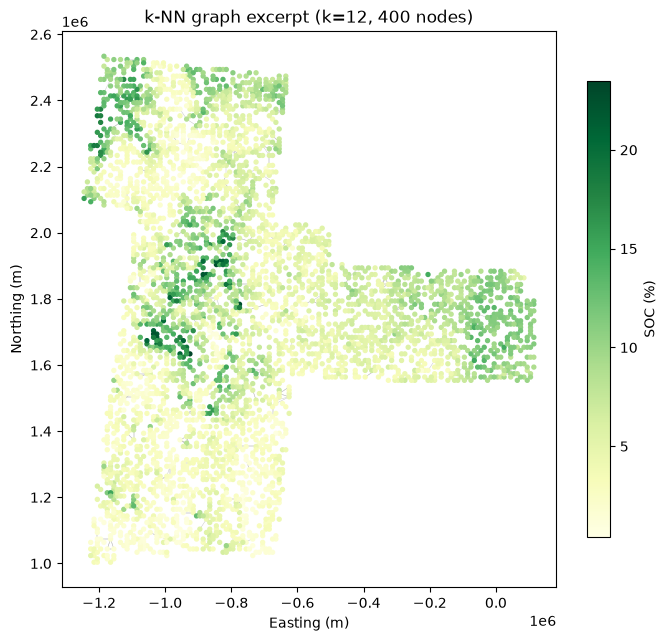

In [12]:
# Visualize a spatial excerpt of the k-NN graph
rk0 = fitted["sage"]
edge_index = rk0.edge_index_.cpu().numpy()
xy = coords_fit
rng = np.random.default_rng(0)
show_n = min(400, len(xy))
keep = set(rng.choice(len(xy), size=show_n, replace=False))
src, dst = edge_index
mask_e = np.array([(int(s) in keep and int(d) in keep) for s, d in zip(src, dst)])

fig, ax = plt.subplots(figsize=(7, 7))
ax.plot(
    np.vstack([xy[src[mask_e], 0], xy[dst[mask_e], 0]]),
    np.vstack([xy[src[mask_e], 1], xy[dst[mask_e], 1]]),
    color="0.75", linewidth=0.3, zorder=1,
)
sc = ax.scatter(xy[:, 0], xy[:, 1], c=y_fit, s=8, cmap="YlGn", zorder=2)
ax.set_aspect("equal", adjustable="box")
ax.set_xlabel("Easting (m)")
ax.set_ylabel("Northing (m)")
ax.set_title(f"k-NN graph excerpt (k={rk0.k_neighbors}, {show_n} nodes)")
fig.colorbar(sc, ax=ax, label="SOC (%)", shrink=0.7)
plt.tight_layout()
plt.show()


***
## 9. Hold-Out Comparison on the Test Set

The models above never saw the test coordinates. For each family we report RMSE, MAE, and $R^2$ of the **full RK prediction** (GNN trend + kriged residual) on the 20% test set.


In [13]:
rows = []
for name, rk in fitted.items():
    y_hat = rk.predict(X_test, coords_test)
    rows.append({
        "family": name,
        "class": type(rk).__name__,
        "k_neighbors": rk.k_neighbors,
        "n_layers": rk.n_layers,
        "hidden_dim": rk.hidden_dim,
        "epochs": len(rk.train_losses_),
        "test_rmse": float(np.sqrt(mean_squared_error(y_test, y_hat))),
        "test_mae": float(mean_absolute_error(y_test, y_hat)),
        "test_r2": float(r2_score(y_test, y_hat)),
        "y_pred_test": y_hat,
    })

results = pd.DataFrame(rows).drop(columns=["y_pred_test"])
results = results.sort_values("test_rmse").reset_index(drop=True)
best_name = results.loc[0, "family"]
display(results)
print(f"Best family by test RMSE: {best_name}")


,family,class,k_neighbors,n_layers,hidden_dim,epochs,test_rmse,test_mae,test_r2
0,sage,GNNRegressionKriging,12,2,64,80,1.162,0.779,0.905
1,ignnk,IGNNK,12,3,64,100,1.208,0.843,0.897
2,kcn,KCN,12,2,64,80,1.210,0.830,0.897
3,gat,GNNRegressionKriging,12,2,64,80,1.536,1.018,0.834


Best family by test RMSE: sage


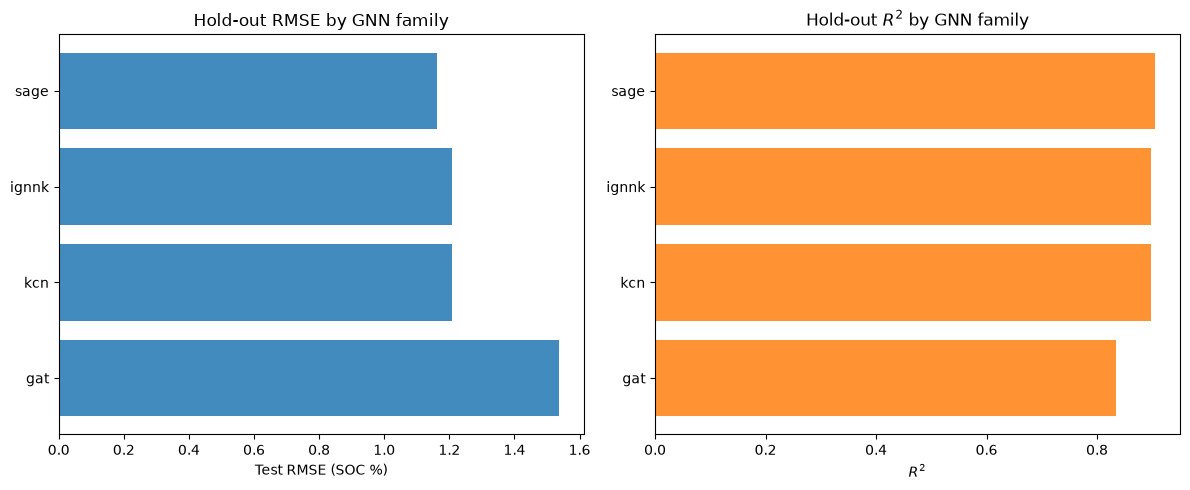

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
order = results.sort_values("test_rmse")
axes[0].barh(order["family"], order["test_rmse"], color="C0", alpha=0.85)
axes[0].set_xlabel("Test RMSE (SOC %)")
axes[0].set_title("Hold-out RMSE by GNN family")
axes[0].invert_yaxis()

axes[1].barh(order["family"], order["test_r2"], color="C1", alpha=0.85)
axes[1].set_xlabel("$R^2$")
axes[1].set_title("Hold-out $R^2$ by GNN family")
axes[1].invert_yaxis()
plt.tight_layout()
plt.show()


### Observed vs predicted on the test set

One-to-one plots for the best family and the other fitted GNNs.


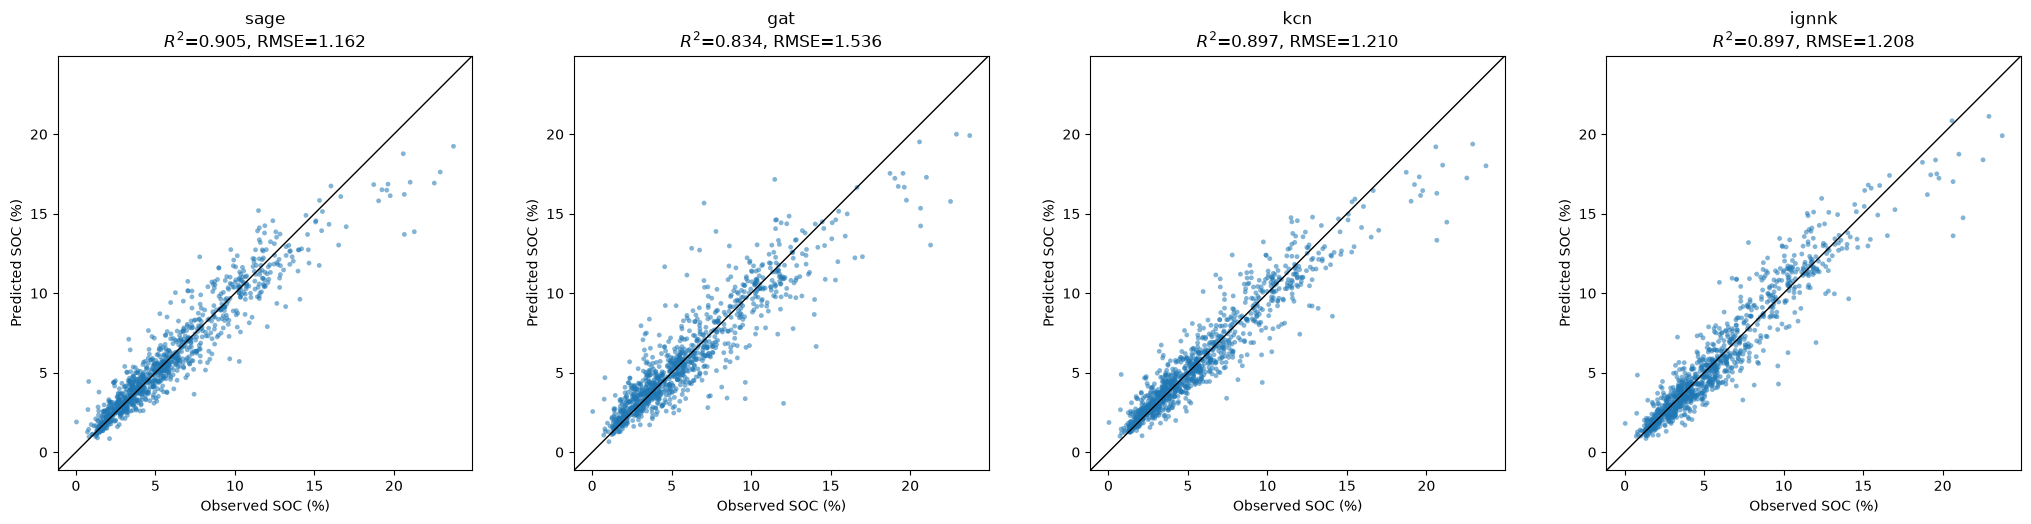

In [15]:
show = [best_name]
for extra in ("sage", "gat", "kcn", "ignnk"):
    if extra in fitted and extra not in show:
        show.append(extra)

pred_lookup = {row["family"]: row for row in rows}
fig, axes = plt.subplots(1, len(show), figsize=(5.2 * len(show), 5.0))
if len(show) == 1:
    axes = [axes]
lims = [
    min(y_test.min(), min(pred_lookup[n]["y_pred_test"].min() for n in show)),
    max(y_test.max(), max(pred_lookup[n]["y_pred_test"].max() for n in show)),
]
pad = 0.05 * (lims[1] - lims[0])
lims = [lims[0] - pad, lims[1] + pad]
for ax, name in zip(axes, show):
    y_hat = pred_lookup[name]["y_pred_test"]
    ax.scatter(y_test, y_hat, s=12, alpha=0.55, edgecolors="none")
    ax.plot(lims, lims, color="black", linewidth=1)
    ax.set_xlim(lims)
    ax.set_ylim(lims)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel("Observed SOC (%)")
    ax.set_ylabel("Predicted SOC (%)")
    r2 = pred_lookup[name]["test_r2"]
    rmse = pred_lookup[name]["test_rmse"]
    ax.set_title(f"{name}\n$R^2$={r2:.3f}, RMSE={rmse:.3f}")
plt.tight_layout()
plt.show()


### Residual variograms of two trend models

The residual variogram depends on the trend: a better neighborhood-aware GNN typically leaves **less structured** residual spatial variation (smaller sill / shorter range).


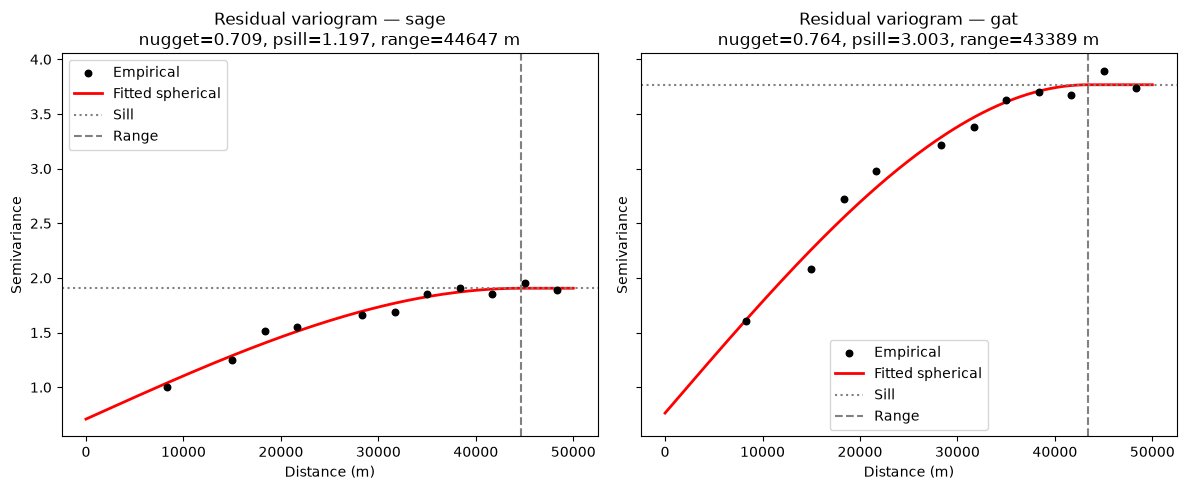

In [16]:
pair = [n for n in (best_name, "sage") if n in fitted]
pair = list(dict.fromkeys(pair))
if len(pair) < 2:
    pair = list(fitted.keys())[:2]

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
for ax, name in zip(axes, pair):
    vg_r = fitted[name].variogram_
    h_fine = np.linspace(0, vg_r.maxlag, 200)
    ax.scatter(vg_r.lags, vg_r.experimental, color="black", s=22, label="Empirical", zorder=3)
    ax.plot(h_fine, vg_r(h_fine), color="red", linewidth=2, label="Fitted spherical")
    c0, c, a = vg_r.fitted_params
    ax.axhline(c0 + c, color="gray", linestyle=":", label="Sill")
    ax.axvline(a, color="gray", linestyle="--", label="Range")
    ax.set_xlabel("Distance (m)")
    ax.set_ylabel("Semivariance")
    ax.set_title(f"Residual variogram — {name}\nnugget={c0:.3f}, psill={c:.3f}, range={a:.0f} m")
    ax.legend()
plt.tight_layout()
plt.show()


***
## 10. Feature Importance

A GNN has no native split-based importances. We report **permutation importance** on the test set: each encoded feature is shuffled in turn, and the increase in RK RMSE is the importance. Residuals depend only on coordinates, so permuting $X$ isolates the **trend** contribution. For KCN/IGNNK the neighborhood still carries observed SOC, so permutation of covariates understates the role of the graph itself.


Baseline test RMSE (sage): 1.162


,feature,importance_mean,importance_std
0,NDVI,0.506,0.018
2,MAT,0.446,0.025
1,MAP,0.282,0.019
4,Slope,0.225,0.020
8,Silt_Clay,0.194,0.008
7,K_Factor,0.113,0.020
9,NLCD_4,0.086,0.011
6,Aspect,0.058,0.006
3,ELEV,0.030,0.006
12,NLCD_7,0.019,0.005


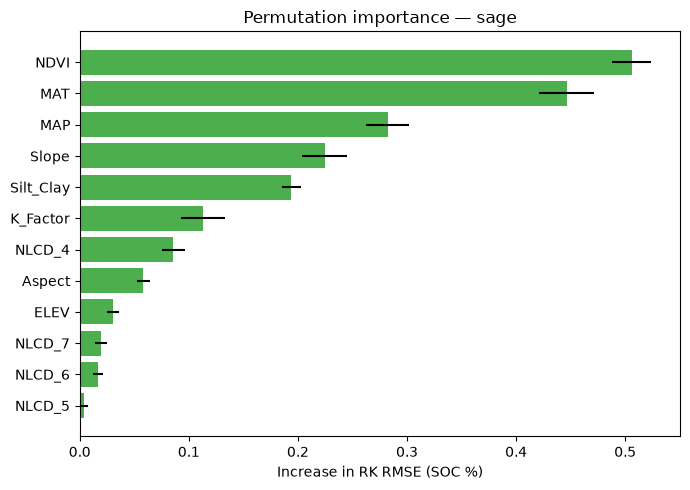

In [17]:
def permutation_importance_rk(rk, X, y, coords, feature_names, n_repeats=8, seed=42):
    baseline = np.sqrt(mean_squared_error(y, rk.predict(X, coords)))
    rng = np.random.default_rng(seed)
    rows = []
    for j, name in enumerate(feature_names):
        deltas = []
        for _ in range(n_repeats):
            Xp = np.array(X, copy=True)
            rng.shuffle(Xp[:, j])
            rmse = np.sqrt(mean_squared_error(y, rk.predict(Xp, coords)))
            deltas.append(rmse - baseline)
        rows.append({
            "feature": name,
            "importance_mean": float(np.mean(deltas)),
            "importance_std": float(np.std(deltas)),
        })
    out = pd.DataFrame(rows).sort_values("importance_mean", ascending=False)
    return baseline, out


best_rk = fitted[best_name]
base_rmse, imp = permutation_importance_rk(
    best_rk, X_test, y_test, coords_test, encoded_feature_names,
)
print(f"Baseline test RMSE ({best_name}): {base_rmse:.3f}")
display(imp.head(12))

fig, ax = plt.subplots(figsize=(7, 5))
top = imp.head(12).iloc[::-1]
ax.barh(top["feature"], top["importance_mean"], xerr=top["importance_std"], color="C2", alpha=0.85)
ax.set_xlabel("Increase in RK RMSE (SOC %)")
ax.set_title(f"Permutation importance — {best_name}")
plt.tight_layout()
plt.show()


***
## 11. Predict SOC on Grid Locations

Each fitted family predicts at the `gp_grid.csv` nodes. For the best family we also store the **regression-only** surface, **kriged residuals**, and kriging standard error.


In [18]:
print("Predicting SOC on the grid for every GNN family ...")
for name, rk in fitted.items():
    grid_df[f"SOC_{name}"] = rk.predict(X_grid, coords_grid)

best_rk = fitted[best_name]
soc_best, se_best = best_rk.predict(X_grid, coords_grid, return_std=True)
grid_df["SOC_best"] = soc_best
grid_df["SOC_best_se"] = se_best

# Regression-only trend = RK prediction minus kriged residual
grid_df["resid_best"] = best_rk.krige_.predict(coords_grid)
grid_df["reg_best"] = grid_df["SOC_best"] - grid_df["resid_best"]

print(grid_df[["x", "y", "SOC_best", "SOC_best_se", "reg_best", "resid_best"]].describe())


Predicting SOC on the grid for every GNN family ...


                 x           y  SOC_best  SOC_best_se  reg_best  resid_best
count    10674.000   10674.000 10674.000    10674.000 10674.000   10674.000
mean   -753412.225 1757164.871     5.988        0.722     5.987       0.001
std     327749.190  382369.477     3.564        0.560     3.357       1.131
min   -1245285.000 1003795.000     0.297        0.000     0.780     -11.434
25%   -1005285.000 1503795.000     3.288        0.000     3.431      -0.546
50%    -825285.000 1743795.000     5.066        1.118     5.081      -0.019
75%    -625285.000 2023795.000     8.034        1.160     7.895       0.481
max     114715.000 2533795.000    23.664        1.360    19.937      10.152


In [19]:
out_path = DATA_DIR / "gp_prediction_RK_gnn.csv"
grid_df.to_csv(out_path, index=False)
print(f"Grid predictions saved to {out_path}")


Grid predictions saved to ../data/gp_prediction_RK_gnn.csv


***
## 12. Map Predictions

Points are plotted in EPSG:5070 with Great Plains state boundaries (`data/GP_STATE.shp`).


In [20]:
states = gpd.read_file(DATA_DIR / "GP_STATE.shp")
gdf_pred = gpd.GeoDataFrame(
    grid_df,
    geometry=gpd.points_from_xy(grid_df.x, grid_df.y),
    crs="EPSG:5070",
)
states = states.to_crs(gdf_pred.crs)


def map_points(ax, column, cmap, title, vmin=None, vmax=None):
    gdf_pred.plot(
        column=column, ax=ax, legend=True, cmap=cmap,
        markersize=4, vmin=vmin, vmax=vmax,
        legend_kwds={"shrink": 0.7},
    )
    states.boundary.plot(ax=ax, color="black", linewidth=0.4)
    ax.set_title(title)
    ax.set_axis_off()


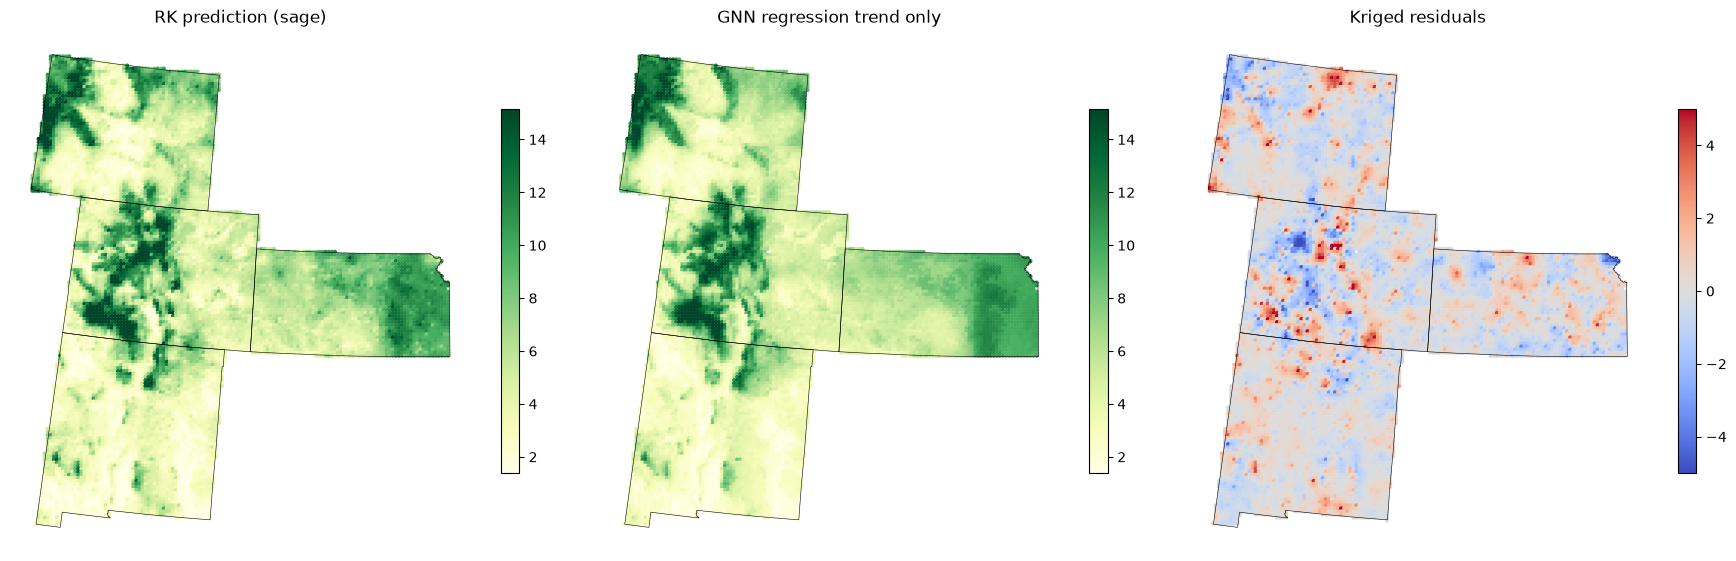

In [21]:
vmin = np.nanpercentile(grid_df["SOC_best"], 2)
vmax = np.nanpercentile(grid_df["SOC_best"], 98)

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
map_points(axes[0], "SOC_best", "YlGn", f"RK prediction ({best_name})", vmin, vmax)
map_points(axes[1], "reg_best", "YlGn", "GNN regression trend only", vmin, vmax)
map_points(axes[2], "resid_best", "coolwarm", "Kriged residuals",
           vmin=-5, vmax=5)
plt.tight_layout()
plt.show()


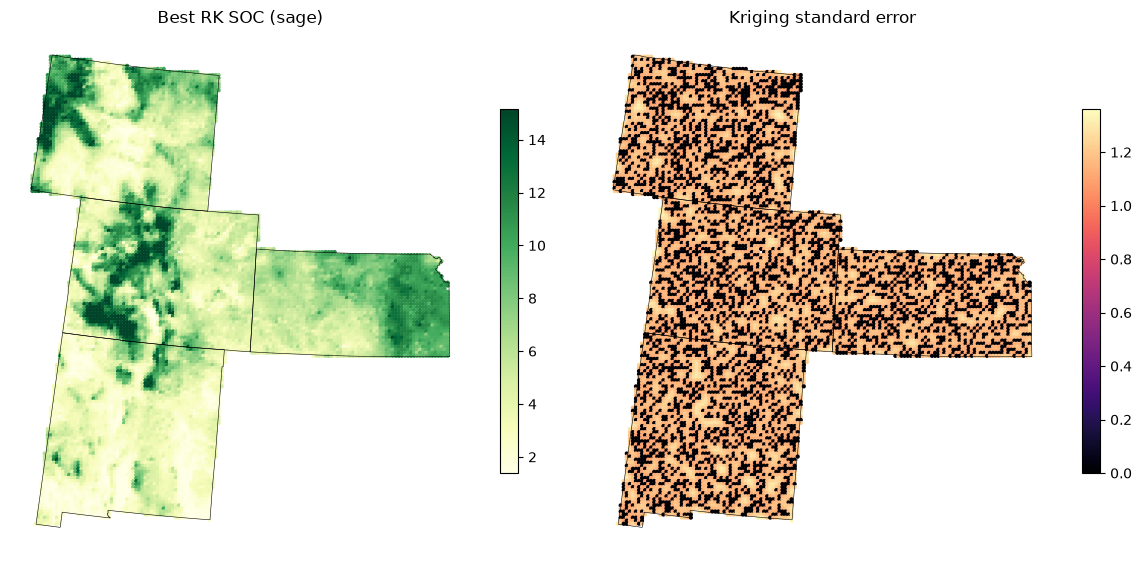

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5.5))
map_points(axes[0], "SOC_best", "YlGn", f"Best RK SOC ({best_name})", vmin, vmax)
map_points(axes[1], "SOC_best_se", "magma", "Kriging standard error")
plt.tight_layout()
plt.show()


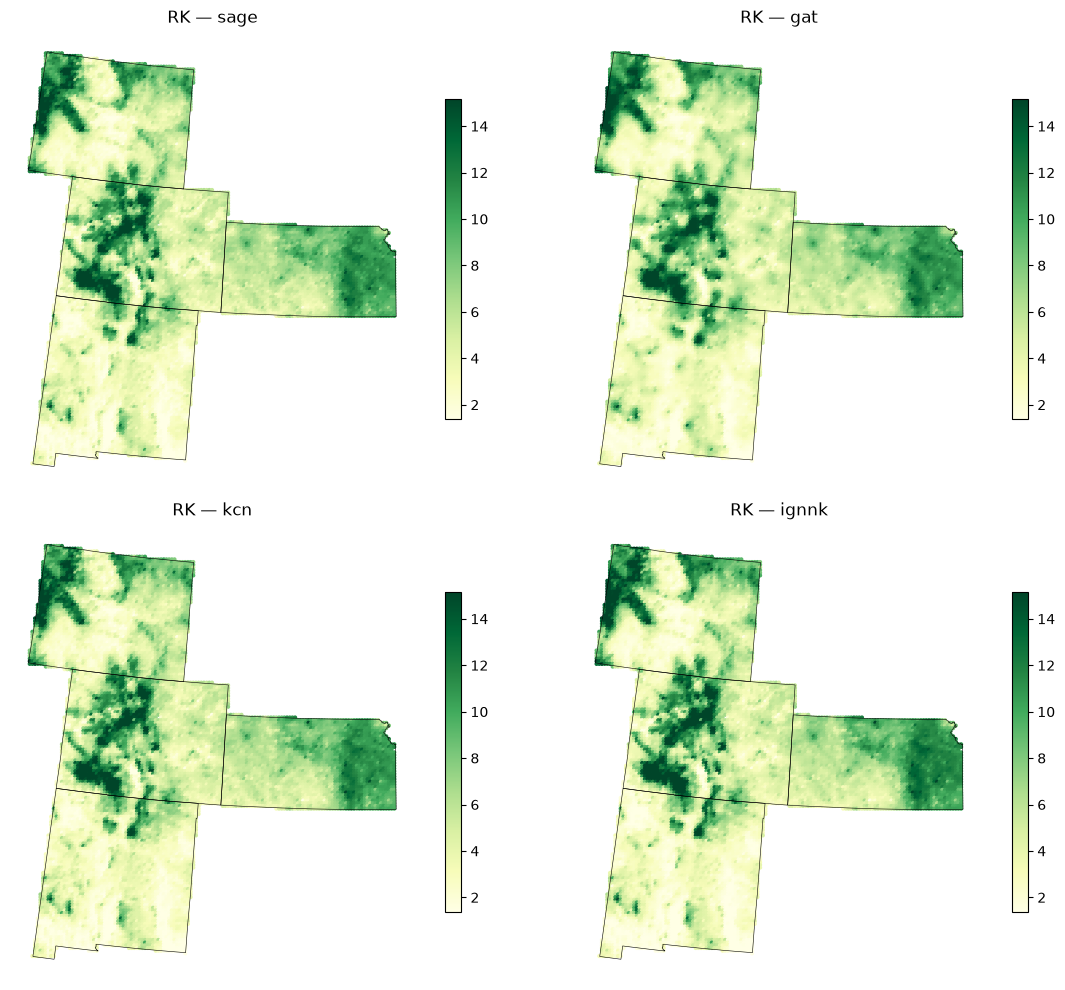

In [23]:
# Side-by-side grid predictions for every GNN family
model_names = list(fitted)
n = len(model_names)
ncols = min(2, n)
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 5 * nrows))
axes = np.atleast_1d(axes).ravel()
for ax, name in zip(axes, model_names):
    map_points(ax, f"SOC_{name}", "YlGn", f"RK — {name}", vmin, vmax)
for ax in axes[n:]:
    ax.axis("off")
plt.tight_layout()
plt.show()


***
## 13. CPU vs GPU RK Timing

Section 3.1 showed how to *select* a backend. Here we measure how long **residual ordinary kriging** — the spatial step inside `GNNRegressionKriging` / `KCN` / `IGNNK` — takes on **CPU** (`use_gpu=False`, NumPy/SciPy) versus **GPU** (`use_gpu=True`, CuPy) for prefixes of the Great Plains SOC survey (`data/gp_data_5000.csv`, $n$ up to 5{,}000).

The GNN trend uses `device=DEVICE` and is **not** part of these timings (training a GNN at every $n$ would dwarf the kriging solve). The GPU-accelerated steps are the $n \times n$ residual covariance among training points, the $n_{\text{pred}} \times n$ covariance to the targets, and the linear solve of the **augmented** OK system. A linear trend (a GNN analogue for residual extraction) is fit once per prefix; that fit and the residual variogram are **not** included in the OK times.

Two practical notes:

- **Small $n$ and few targets** (a few hundred training *and* prediction points) often shows little GPU gain: host→device copies and kernel-launch overhead dominate.
- **Larger $n$**, or a **dense prediction grid**, is where the GPU pays off: the OK system scales as $O(n^3)$ for the solve and $O(n \cdot n_{\text{pred}})$ for the target covariances.

Each timing is the **median** of three `OrdinaryKriging.fit` + `predict(..., return_variance=True)` calls after a short GPU warmup so CUDA kernel compilation is not counted. If CuPy cannot run a kernel here, the GPU column is skipped and only CPU times are reported.


GPU usable : True
Repeats    : 3  (median wall time of residual OK fit + predict)
GP SOC     : 5000 samples from data/gp_data_5000.csv
Trend      : linear (GNN analogue; residual OK uses use_gpu)
GP n_pred  : 500 grid locations

 dataset  n_train  n_pred  CPU (ms)  GPU (ms) speedup  match
GP (SOC)      500     500      60.1       9.9   6.04×   True
GP (SOC)     1000     500     142.8      24.4   5.86×   True
GP (SOC)     2000     500     378.0      62.3   6.07×   True
GP (SOC)     4000     500    1358.0     208.0   6.53×   True
GP (SOC)     5000     500    2136.5     351.9   6.07×   True



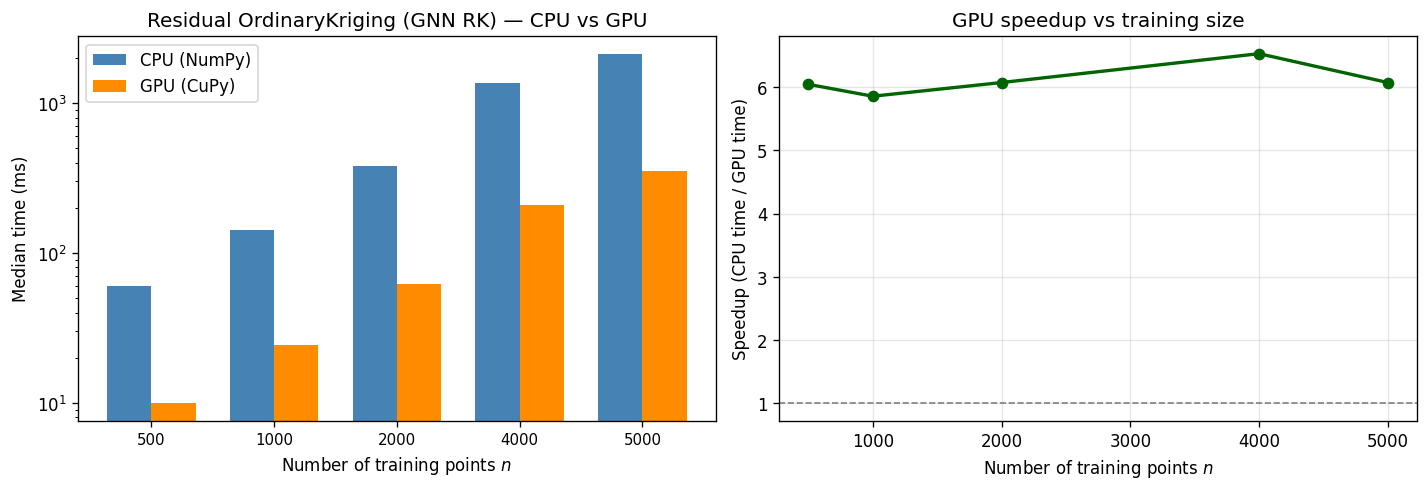

In [22]:
import time
from sklearn.linear_model import LinearRegression

from pygstat import OrdinaryKriging

N_REPEATS = 3
N_PRED_GP = 500
GP_SIZES = [500, 1000, 2000, 4000, 5000]
rng_bench = np.random.default_rng(42)

pred_idx = rng_bench.choice(len(coords_grid), size=N_PRED_GP, replace=False)
xy_pred_b = coords_grid[pred_idx]


def _residual_variogram(X_tr, y_tr, xy_tr):
    """Linear trend (CPU); residual field is what OK interpolates."""
    lin = LinearRegression().fit(np.asarray(X_tr, dtype=float), y_tr)
    resid = y_tr - lin.predict(np.asarray(X_tr, dtype=float))
    vg_kw = dict(VARIOGRAM_KWARGS)
    vg_kw.pop("use_gpu", None)
    return Variogram(
        np.asarray(xy_tr, dtype=float),
        np.asarray(resid, dtype=float),
        model="spherical",
        estimator="matheron",
        use_gpu=False,
        **vg_kw,
    ).fit(), resid


def _time_ok(xy_train, z_train, xy_pred, vg, use_gpu, repeats=N_REPEATS, warmup=True):
    """Median wall time of OrdinaryKriging.fit + predict(return_variance=True)."""
    if warmup:
        k_tr = min(40, len(xy_train))
        k_pr = min(40, len(xy_pred))
        OrdinaryKriging(vg, use_gpu=use_gpu).fit(
            xy_train[:k_tr], z_train[:k_tr]
        ).predict(xy_pred[:k_pr], return_variance=True)
        if use_gpu:
            import cupy as cp
            cp.cuda.Device(0).synchronize()
    times = []
    last = None
    for _ in range(repeats):
        t0 = time.perf_counter()
        ok_m = OrdinaryKriging(vg, use_gpu=use_gpu).fit(xy_train, z_train)
        last = ok_m.predict(xy_pred, return_variance=True)
        if use_gpu:
            import cupy as cp
            cp.cuda.Device(0).synchronize()
        times.append(time.perf_counter() - t0)
    return float(np.median(times)), last


print(f"GPU usable : {USE_GPU}")
print(f"Repeats    : {N_REPEATS}  (median wall time of residual OK fit + predict)")
print(f"GP SOC     : {len(y)} samples from data/gp_data_5000.csv")
print("Trend      : linear (GNN analogue; residual OK uses use_gpu)")
print(f"GP n_pred  : {N_PRED_GP} grid locations")
print()

rows = []
for n in GP_SIZES:
    X_tr = np.asarray(X[:n], dtype=float)
    y_tr = y[:n]
    xy_tr = coords[:n]
    vg, resid = _residual_variogram(X_tr, y_tr, xy_tr)

    cpu_t, pred_cpu = _time_ok(xy_tr, resid, xy_pred_b, vg, use_gpu=False)
    row = {
        "dataset": "GP (SOC)",
        "n_train": n,
        "n_pred": N_PRED_GP,
        "CPU (s)": cpu_t,
        "GPU (s)": np.nan,
        "speedup": np.nan,
        "match": "—",
    }
    if USE_GPU:
        gpu_t, pred_gpu = _time_ok(xy_tr, resid, xy_pred_b, vg, use_gpu=True)
        row["GPU (s)"] = gpu_t
        row["speedup"] = cpu_t / gpu_t
        z_c, se_c = pred_cpu
        z_g, se_g = pred_gpu
        row["match"] = bool(
            np.allclose(z_c, z_g, rtol=1e-4, atol=1e-4, equal_nan=True)
            and np.allclose(se_c, se_g, rtol=1e-4, atol=1e-4, equal_nan=True)
        )
        import cupy as cp
        cp.get_default_memory_pool().free_all_blocks()
    rows.append(row)

df_bench = pd.DataFrame(rows)
df_show = df_bench.copy()
df_show["CPU (ms)"] = (df_show["CPU (s)"] * 1000).round(1)
df_show["GPU (ms)"] = (df_show["GPU (s)"] * 1000).round(1)
df_show["speedup"] = df_show["speedup"].map(
    lambda x: "—" if pd.isna(x) else f"{x:.2f}×"
)
print(df_show[["dataset", "n_train", "n_pred", "CPU (ms)", "GPU (ms)", "speedup", "match"]].to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
n_vals = df_bench["n_train"].to_numpy()
cpu_ms = df_bench["CPU (s)"].to_numpy() * 1000
gpu_ms = df_bench["GPU (s)"].to_numpy() * 1000
labels = [str(int(n)) for n in n_vals]

x = np.arange(len(n_vals))
w = 0.36
axes[0].bar(x - w / 2, cpu_ms, w, label="CPU (NumPy)", color="steelblue")
if USE_GPU and np.isfinite(gpu_ms).all():
    axes[0].bar(x + w / 2, gpu_ms, w, label="GPU (CuPy)", color="darkorange")
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels, fontsize=9)
axes[0].set_xlabel("Number of training points $n$")
axes[0].set_ylabel("Median time (ms)")
axes[0].set_title("Residual OrdinaryKriging (GNN RK) — CPU vs GPU")
axes[0].legend()
axes[0].set_yscale("log")

if USE_GPU:
    axes[1].plot(n_vals, df_bench["speedup"], "o-", color="darkgreen", lw=2)
    axes[1].axhline(1.0, color="grey", ls="--", lw=1)
    axes[1].set_xlabel("Number of training points $n$")
    axes[1].set_ylabel("Speedup (CPU time / GPU time)")
    axes[1].set_title("GPU speedup vs training size")
    axes[1].grid(True, alpha=0.3)
else:
    axes[1].text(
        0.5, 0.5,
        "GPU not usable in this environment\nCPU-only timings shown",
        ha="center", va="center", transform=axes[1].transAxes,
    )
    axes[1].set_axis_off()

plt.tight_layout()
plt.show()


Predictions and residual-kriging standard errors from the two backends should **match** (`match = True`). The GNN trend is independent of this comparison; the GPU speedup comes from the residual OK covariance build and solve. On the Great Plains SOC prefixes the $O(n^2)$ covariance and $O(n^3)$ solve keep the GPU several times faster as $n$ grows to 5{,}000. Use `use_gpu=USE_GPU` (as the rest of this notebook does) so the same cells run on a laptop CPU or a CUDA workstation without edits.


***
## 14. Summary and Conclusions

This notebook applied **regression kriging** to Great Plains **soil organic carbon** with **graph neural network** trends (`pygstat.GNNRegressionKriging`, `KCN`, `IGNNK`).

- **Data.** 5,000 samples (`gp_data_5000.csv`) and a 10 km grid (`gp_grid.csv`). **NLCD** is a **categorical** land-cover class, dummy-encoded with `OneHotEncoder(drop="first")` rather than treated as an ordinal score.
- **Graph.** Each sample is a node; edges are $k$-nearest neighbors in Albers metres ($k=12$). New grid nodes are attached inductively to training neighbors only.
- **Split.** NLCD-stratified **60% train / 20% valid / 20% test**. Train+valid form the GNN graph; an internal `val_fraction` provides early stopping; test is used only for the final comparison.
- **Families.** **GraphSAGE-mean**, **GAT**, **KCN** (leave-self-out Gaussian-kernel convolution of neighbor SOC), and **IGNNK** (random-mask reconstruction) were each scored on the test set. The **best of the four** was used to map SOC on the grid.
- **Mapping.** SOC, the GNN trend, kriged residuals, and kriging standard error were written to `data/gp_prediction_RK_gnn.csv`.
- **CPU / GPU.** Residual ordinary kriging (`use_gpu=USE_GPU`) was timed on prefixes of `gp_data_5000.csv`. The GNN uses `device=DEVICE`; the $O(n^2)$ covariance and $O(n^3)$ OK solve are the CuPy-accelerated steps.

Regression kriging with a GNN trend is a practical workflow when you want **neighborhood-aware nonlinear capacity** (and, with KCN/IGNNK, propagation of observed values along the spatial graph) **plus geostatistical residuals** on the same spatial support. It does not replace kriging's BLUE guarantee or analytic variance — that is still the residual-kriging step.


***
## 15. Resources

### Papers and books

| Reference | Notes |
|-----------|-------|
| Gilmer, J. et al. (2017). Neural message passing for quantum chemistry. *ICML*. | Message-passing framework used in §1.1 |
| Kipf, T.N. & Welling, M. (2017). Semi-supervised classification with graph convolutional networks. *ICLR*. | Classic GCN layer |
| Hamilton, W.L., Ying, R. & Leskovec, J. (2017). Inductive representation learning on large graphs. *NeurIPS*. | GraphSAGE; inductive aggregation |
| Veličković, P. et al. (2018). Graph attention networks. *ICLR*. | GAT (`conv_type='gat'`) |
| Appleby, G., Liu, L. & Liu, L. (2020). Kriging convolutional networks. *AAAI*. [arXiv:1907.05003](https://arxiv.org/abs/1907.05003) | KCN: distance-kernel, leave-self-out convolution |
| Wu, Y., Cui, D., Nie, F. & Wang, H. (2021). Inductive graph neural networks for spatiotemporal kriging. *AAAI*. [arXiv:2006.07527](https://arxiv.org/abs/2006.07527) | IGNNK: random-mask reconstruction |
| Hengl, T., Heuvelink, G.B.M. & Stein, A. (2004). A generic framework for spatial prediction of soil variables based on regression-kriging. *Geoderma* 120, 75–93. | RK as used in digital soil mapping |
| Hengl, T., Heuvelink, G.B.M. & Rossiter, D.G. (2007). About regression-kriging: from equations to case studies. *Computers & Geosciences* 33, 1301–1315. | Practical RK workflow |
| Goovaerts, P. (1997). *Geostatistics for Natural Resources Evaluation*. Oxford University Press. | SK with a varying local mean |

### In this library

| Object | Role |
|--------|------|
| `pygstat.GNNRegressionKriging` | Covariate-only spatial GNN trend + ordinary kriging of residuals (`use_gpu`) |
| `conv_type='mean'` / `'gat'` | GraphSAGE-style mean aggregation vs. graph attention |
| `pygstat.KCN` | Kriging Convolutional Network trend (leave-self-out Gaussian kernel) + residual kriging |
| `pygstat.IGNNK` | Inductive masked-reconstruction GNN trend + residual kriging |
| `k_neighbors` | Number of spatial nearest neighbors per node |
| `mask_ratio` | IGNNK: fraction of nodes hidden each training epoch |
| `fit(..., val_fraction=)` | Internal early-stopping split; validation nodes stay in the graph |
| `predict(..., return_std=True)` | RK prediction plus residual kriging standard error |
| `variogram_`, `krige_`, `train_losses_`, `val_losses_` | Fitted residual variogram, OK model, and training curves |
| `pygstat.Variogram` | Residual (and exploratory) variogram |

Install extras with `pip install pygstat[pytorch]`. Residual OK uses `use_gpu=USE_GPU` (CuPy). Set `device='cuda'` to force a PyTorch GPU, or leave `device='auto'` (used here via `DEVICE`) to fall back to CPU when CUDA is unavailable. Related tutorials: [6.1 scikit-learn RK](06_01_regression_kriging_scikit_learn.ipynb), [6.2 H2O RK](06_02_regression_kriging_H20.ipynb), [6.3 PyTorch MLP RK](06_03_regression_kriging_pytorch.ipynb), [6.4 TensorFlow DNN RK](06_04_regression_krigingDNN_TF.ipynb).
